# CrunchTheData



The analysis on anime dataset. (Year 2023)






I have chosen the name of the project as CrunchTheData as I am working on anime dataset so Crunchyroll + Data = CruchTheData.


Phase 1: Data Acquisition and Cleaning


I am working on anime dataset from kaggle.
__The dataset URL:__ https://www.kaggle.com/datasets/unibahmad/anime-dataset/data

The source of the data is from datahub.io


The "Anime TV Shows Database" is a comprehensive collection of data related to various anime TV shows. This dataset provides a wealth of information about anime series, including details about their production, ratings, related shows, genres, and more.

__Key Features and Attributes:__

Basic Information: Includes the title of the show, its type (e.g., TV, OVA, Movie), the year of release, and the season it premiered.

Production and Studios: Contains information about the studios responsible for producing the anime series, along with studio locations.

Ranking and Ratings: Provides details on the ranking of each show, user ratings, and any available reviews.

Related Shows and Franchises: Lists related shows and provides information about any franchises to which the show belongs.

It has around 18.5k rows and 17 columns.



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#data import
data="Anime.csv"
anime_original_df = pd.read_csv(data)

In [3]:
#View first rows
anime_original_df.head()

,Rank,Name,Japanese_name,Type,Episodes,Studio,Release_season,Tags,Rating,Release_year,End_year,Description,Content_Warning,Related_Mange,Related_anime,Voice_actors,staff
0,1,Demon Slayer: Kimetsu no Yaiba - Entertainment...,Kimetsu no Yaiba: Yuukaku-hen,TV,NaN,ufotable,Fall,"Action, Adventure, Fantasy, Shounen, Demons, H...",4.60,2021.0,NaN,'Tanjiro and his friends accompany the Hashira...,Explicit Violence,Demon Slayer: Kimetsu no Yaiba,"Demon Slayer: Kimetsu no Yaiba, Demon Slayer: ...","Inosuke Hashibira : Yoshitsugu Matsuoka, Nezuk...","Koyoharu Gotouge : Original Creator, Haruo Sot..."
1,2,Fruits Basket the Final Season,Fruits Basket the Final,TV,13.0,TMS Entertainment,Spring,"Drama, Fantasy, Romance, Shoujo, Animal Transf...",4.60,2021.0,NaN,'The final arc of Fruits Basket.',"Emotional Abuse,, Mature Themes,, Physical Abu...","Fruits Basket, Fruits Basket Another","Fruits Basket 1st Season, Fruits Basket 2nd Se...","Akito Sohma : Maaya Sakamoto, Kyo Sohma : Yuum...","Natsuki Takaya : Original Creator, Yoshihide I..."
2,3,Mo Dao Zu Shi 3,The Founder of Diabolism 3,Web,12.0,B.C MAY PICTURES,NaN,"Fantasy, Ancient China, Chinese Animation, Cul...",4.58,2021.0,NaN,'The third season of Mo Dao Zu Shi.',NaN,Grandmaster of Demonic Cultivation: Mo Dao Zu ...,"Mo Dao Zu Shi 2, Mo Dao Zu Shi Q","Lan Wangji, Wei Wuxian, Jiang Cheng, Jin Guang...","Mo Xiang Tong Xiu : Original Creator, Xiong Ke..."
3,4,Fullmetal Alchemist: Brotherhood,Hagane no Renkinjutsushi: Full Metal Alchemist,TV,64.0,Bones,Spring,"Action, Adventure, Drama, Fantasy, Mystery, Sh...",4.58,2009.0,2010.0,"""The foundation of alchemy is based on the law...","Animal Abuse,, Mature Themes,, Violence,, Dome...","Fullmetal Alchemist, Fullmetal Alchemist (Ligh...","Fullmetal Alchemist: Brotherhood Specials, Ful...","Alphonse Elric : Rie Kugimiya, Edward Elric : ...","Hiromu Arakawa : Original Creator, Yasuhiro Ir..."
4,5,Attack on Titan 3rd Season: Part II,Shingeki no Kyojin Season 3: Part II,TV,10.0,WIT Studio,Spring,"Action, Fantasy, Horror, Shounen, Dark Fantasy...",4.57,2019.0,NaN,'The battle to retake Wall Maria begins now! W...,"Cannibalism,, Explicit Violence","Attack on Titan, Attack on Titan: End of the W...","Attack on Titan, Attack on Titan 2nd Season, A...","Armin Arlelt : Marina Inoue, Eren Jaeger : Yuu...","Hajime Isayama : Original Creator, Tetsurou Ar..."


In [4]:
#view information
anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18495 entries, 0 to 18494
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             18495 non-null  int64  
 1   Name             18495 non-null  object 
 2   Japanese_name    7938 non-null   object 
 3   Type             18495 non-null  object 
 4   Episodes         9501 non-null   float64
 5   Studio           12018 non-null  object 
 6   Release_season   4116 non-null   object 
 7   Tags             18095 non-null  object 
 8   Rating           15364 non-null  float64
 9   Release_year     18112 non-null  float64
 10  End_year         2854 non-null   float64
 11  Description      18491 non-null  object 
 12  Content_Warning  1840 non-null   object 
 13  Related_Mange    7627 non-null   object 
 14  Related_anime    10063 non-null  object 
 15  Voice_actors     15309 non-null  object 
 16  staff            13005 non-null  object 
dtypes: float64(4

In [5]:
#View statistical data
anime_original_df.describe()

,Rank,Episodes,Rating,Release_year,End_year
count,18495.00000,9501.000000,15364.000000,18112.000000,2854.000000
mean,9248.00000,20.920850,3.355133,2006.520318,2004.256132
std,5339.19095,37.990858,0.400624,15.189537,13.257484
min,1.00000,1.000000,0.960000,1907.000000,1962.000000
25%,4624.50000,2.000000,3.130000,2001.000000,1996.000000
50%,9248.00000,12.000000,3.360000,2012.000000,2007.000000
75%,13871.50000,26.000000,3.590000,2017.000000,2015.000000
max,18495.00000,800.000000,4.600000,2023.000000,2022.000000


# Data Cleaning:

After inspecting the data, we see there are many values which are null, the column name needs to be lower cased and this dataset has many columns so we need to drop the few columns as we are not cosidering them into our calculation going forward.



__1. Coulmn Name:__
    It may not seem like a big deal, but let's modify the column names. Let's make them all lowercase for consistency and generally being easier to type when referenced. Additionally, we should remove any leading or training white-spaces.
    
   

In [6]:
## Fix up the Columns
anime_original_df.columns=anime_original_df.columns.str.strip().str.lower() #removes white space and makes it lower case
anime_original_df.columns

Index(['rank', 'name', 'japanese_name', 'type', 'episodes', 'studio',
       'release_season', 'tags', 'rating', 'release_year', 'end_year',
       'description', 'content_warning', 'related_mange', 'related_anime',
       'voice_actors', 'staff'],
      dtype='object')


__2. Remove the columns:__
   
   For our analysis we need below columns, we can remove other columns.

   columns needed: rank,name,japanese_name,type,episodes,studeio,release_season,ratings,release_year
   

In [7]:
columns=['rank', 'name', 'type', 'studio', 'tags', 'rating', 'release_year']

anime_original_df=anime_original_df[columns]

anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18495 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18495 non-null  int64  
 1   name          18495 non-null  object 
 2   type          18495 non-null  object 
 3   studio        12018 non-null  object 
 4   tags          18095 non-null  object 
 5   rating        15364 non-null  float64
 6   release_year  18112 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 1011.6+ KB


__3. Change of DataType:__
   
   Episodes data type chnaging from float to int and release_year data type from float to year


In [8]:
#Converting data type of release_year
anime_original_df['release_year']= anime_original_df['release_year'].astype('Int64')

anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18495 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18495 non-null  int64  
 1   name          18495 non-null  object 
 2   type          18495 non-null  object 
 3   studio        12018 non-null  object 
 4   tags          18095 non-null  object 
 5   rating        15364 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.0+ MB


__4. Filling NaN and Null Values__
   
   In the dataset we have studio,tags,ratings and release_year, which has NaN and null values.
   
   First Lets check for NaN values in all the three columns and if all the three columns have NaN value, then we will drop those rows as sufficient information is not available and filling those row with the information will be a tidious work. Therefore before filling those rows with Unknown, if the all the three coulmns has NaN value then we will drop those columns

In [9]:
#to check which anme missing the relase year, studio and ratings


mask=anime_original_df["release_year"].isna() & anime_original_df["rating"].isna() & anime_original_df["studio"].isna()
anime_original_df[mask]


#dropping those values as  not having those values will be difficult to insert the data into.
anime_original_df.dropna(subset=["release_year", "rating", "studio"], how="all", inplace=True)


In [10]:
anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18254 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18254 non-null  int64  
 1   name          18254 non-null  object 
 2   type          18254 non-null  object 
 3   studio        12018 non-null  object 
 4   tags          17857 non-null  object 
 5   rating        15364 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB




Initially I planned to Fill NaN values for release_year, ratings the median value. As filling the median value the statistic data of the dataset does not change.

However with the feedback I recieved, I rethought about filling the those values as median value, which might not be a good idea, instead checking on the data which has NaN value for year and then decide on the what to do on those values



In [11]:
mask = anime_original_df["release_year"].isna() & anime_original_df["rating"].isna()
anime_original_df[mask]


,rank,name,type,studio,tags,rating,release_year
15385,15386,Xixing Ji Movie: Qiong Qi Didong,Movie,BYMENT,"Adventure, Chinese Animation, Based on a Manga...",NaN,<NA>
15419,15420,Xixing Ji 4th Season,Web,BYMENT,"Adventure, Chinese Animation, Based on a Manga...",NaN,<NA>
15437,15438,Mobile Suit Gundam: Hathaway's Flash II,Movie,Sunrise,"Action, Mecha, Sci Fi, Military, Outer Space, ...",NaN,<NA>
15438,15439,Mobile Suit Gundam: Hathaway's Flash III,Movie,Sunrise,"Action, Mecha, Sci Fi, Military, Outer Space, ...",NaN,<NA>
15522,15523,Deep Sea,Movie,October Media,"Adventure, Fantasy, Chinese Animation, CG Anim...",NaN,<NA>
...,...,...,...,...,...,...,...
18420,18421,Kitarou Tanjou: Gegege no Nazo,Movie,Toei Animation,"Shounen, Japanese Mythology, Supernatural, You...",NaN,<NA>
18429,18430,Beastars Final Season,Web,Orange,"Action, Drama, Fantasy, Animal Protagonists, A...",NaN,<NA>
18461,18462,Hua Jianghu Zhi Gui Yexing: Part II,Web,Beijing Rocen,"Action, Sports, Cars, Chinese Animation, Racin...",NaN,<NA>
18479,18480,Baise Shandian,Web,HuaMei Animation,"Sports, Chinese Animation, Ping Pong",NaN,<NA>


Here I checked if both rating and realse year data is unavailable. 

Found few values for that. we will be removing those values to make our analysis easy.

In [12]:
#checking of rating and realease year is null 
mask= anime_original_df["release_year"].isna() & anime_original_df["rating"].isna()

#dropping those values
anime_original_df = anime_original_df.dropna(subset=["release_year", "rating"], how="all")

anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18132 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18132 non-null  int64  
 1   name          18132 non-null  object 
 2   type          18132 non-null  object 
 3   studio        11896 non-null  object 
 4   tags          17735 non-null  object 
 5   rating        15364 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB




For the Null values in the studio and tags columns, I have filled it it with Unknown



In [13]:
#lets fill the studio column with unknown

anime_original_df["studio"]=anime_original_df["studio"].fillna("Unknown")
anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18132 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18132 non-null  int64  
 1   name          18132 non-null  object 
 2   type          18132 non-null  object 
 3   studio        18132 non-null  object 
 4   tags          17735 non-null  object 
 5   rating        15364 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB


In [14]:
#Tags also will be filled as unknown 

anime_original_df["tags"]=anime_original_df["tags"].fillna("Unknown")
anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18132 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18132 non-null  int64  
 1   name          18132 non-null  object 
 2   type          18132 non-null  object 
 3   studio        18132 non-null  object 
 4   tags          18132 non-null  object 
 5   rating        15364 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB


The rating coulmn is  filled with median of the values.

In [15]:
#ratings will fill the median value again. as deleting those columns may lose a lot data 


mask= anime_original_df["rating"].median() #3.36
anime_original_df["rating"]=anime_original_df["rating"].fillna(mask)


anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18132 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18132 non-null  int64  
 1   name          18132 non-null  object 
 2   type          18132 non-null  object 
 3   studio        18132 non-null  object 
 4   tags          18132 non-null  object 
 5   rating        18132 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB


Remaing of the release year will year will delete as filling those values with median values would not be correct.

In [16]:
mask =anime_original_df["release_year"].isna()
anime_original_df = anime_original_df.drop(anime_original_df[mask].index)
anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18112 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18112 non-null  int64  
 1   name          18112 non-null  object 
 2   type          18112 non-null  object 
 3   studio        18112 non-null  object 
 4   tags          18112 non-null  object 
 5   rating        18112 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB


Now our data is ready to use. No we do not have null values and initially we had 18495 and after cleaning we have 18254 values.
Below are the information and statictic information of the cleaned data. 

In [17]:
##View head value
anime_original_df.head(10)

,rank,name,type,studio,tags,rating,release_year
0,1,Demon Slayer: Kimetsu no Yaiba - Entertainment...,TV,ufotable,"Action, Adventure, Fantasy, Shounen, Demons, H...",4.60,2021
1,2,Fruits Basket the Final Season,TV,TMS Entertainment,"Drama, Fantasy, Romance, Shoujo, Animal Transf...",4.60,2021
2,3,Mo Dao Zu Shi 3,Web,B.C MAY PICTURES,"Fantasy, Ancient China, Chinese Animation, Cul...",4.58,2021
3,4,Fullmetal Alchemist: Brotherhood,TV,Bones,"Action, Adventure, Drama, Fantasy, Mystery, Sh...",4.58,2009
4,5,Attack on Titan 3rd Season: Part II,TV,WIT Studio,"Action, Fantasy, Horror, Shounen, Dark Fantasy...",4.57,2019
5,6,Jujutsu Kaisen,TV,MAPPA,"Action, Horror, Shounen, Curse, Exorcists, Mon...",4.56,2020
6,7,Attack on Titan The Final Season: Part II,TV,MAPPA,"Action, Drama, Fantasy, Horror, Shounen, Dark ...",4.56,2022
7,8,Attack on Titan The Final Season,TV,MAPPA,"Action, Drama, Fantasy, Horror, Shounen, Dark ...",4.55,2020
8,9,Demon Slayer: Kimetsu no Yaiba Movie - Mugen T...,Movie,ufotable,"Action, Drama, Fantasy, Shounen, Demons, Histo...",4.54,2020
9,10,Haikyuu!! Karasuno High School vs Shiratorizaw...,TV,Production I.G,"Shounen, Sports, Animeism, School Club, School...",4.53,2016


In [18]:
## Display Statistical Information

anime_original_df.describe()

,rank,rating,release_year
count,18112.000000,18112.000000,18112.0
mean,9093.620031,3.356045,2006.520318
std,5278.196185,0.368696,15.189537
min,1.000000,0.960000,1907.0
25%,4530.750000,3.170000,2001.0
50%,9068.500000,3.360000,2012.0
75%,13601.250000,3.540000,2017.0
max,18495.000000,4.600000,2023.0


In [19]:
## View Information

anime_original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18112 entries, 0 to 18494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          18112 non-null  int64  
 1   name          18112 non-null  object 
 2   type          18112 non-null  object 
 3   studio        18112 non-null  object 
 4   tags          18112 non-null  object 
 5   rating        18112 non-null  float64
 6   release_year  18112 non-null  Int64  
dtypes: Int64(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB


Phase 2: Exploratory Data Analysis (EDA)




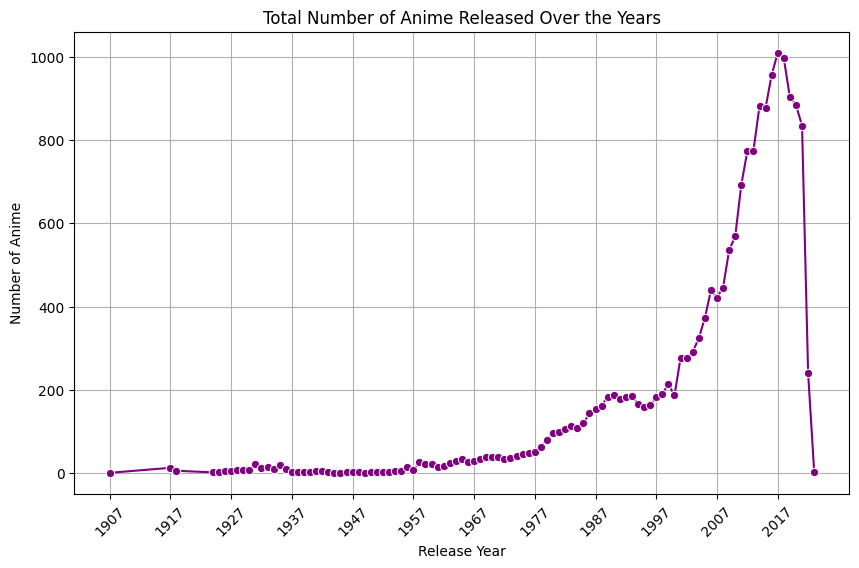

In [20]:
anime_per_year = anime_original_df.groupby('release_year')['name'].count()

plt.figure(figsize=(10,6))
sns.lineplot(x=anime_per_year.index, y=anime_per_year.values, marker='o', color='purple')
plt.title("Total Number of Anime Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Anime")

start_year = anime_per_year.index.min()
end_year = anime_per_year.index.max()
plt.xticks(range(start_year, end_year+1, 10), rotation=45)

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Observation:
https://mipon.org/anime-industry-facts/#:~:text=From%202000%20to%202010%2C%20an,about%20the%20production%20of%20anime.

We see that around the time 2015-2018 highest number of anime released. according to the report shared above:

In 2016, the number of anime produced per year reached its peak, with a record of 356 anime. Since 2017 though, as you can see in the graph, that number has been decreasing. In 2020, it is estimated that 278 anime were produced, meaning that it was a decrease of 22% from 2016 to 2020. 

Is it due to a loss in demand for anime? 

In 2019, the decrease in production was likely caused by a decrease in sales in the Chinese market, on top of the postponement of TV broadcasts in Japan. 

In 2020, due to COVID-19, productions were temporarily suspended and/or had their broadcasts delayed.


But that doesn’t mean that the demand for anime productions is decreasing. In fact, it’s still huge.


As we saw above hightest number of anime released during the period of 2015-2018,lets consider the data 2007 to 2023 and find the highest rated anime in each year. and display it with the help of bar graph along with the highest rated anime title.



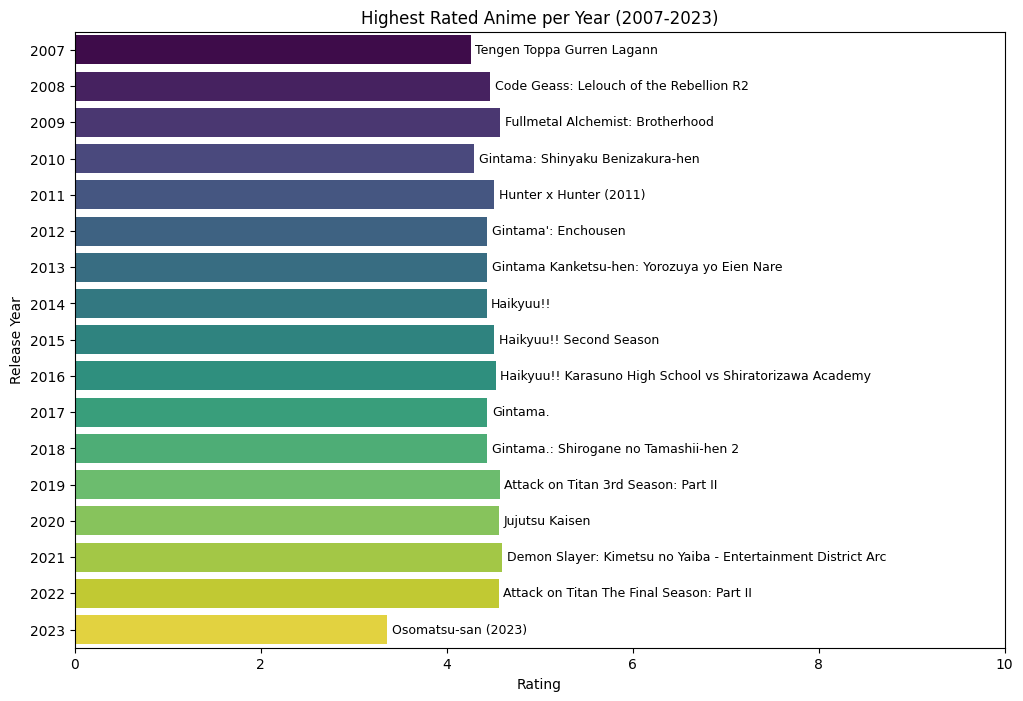

In [21]:
#Listing the highest rated anime over the year 2007-2023

# Filter for years 2007-2023
df_filtered = anime_original_df[(anime_original_df['release_year'] >= 2007) & (anime_original_df['release_year'] <= 2023)].dropna(subset=['release_year'])

# Find the highest rated anime per year
highest_per_year = df_filtered.loc[df_filtered.groupby('release_year')['rating'].idxmax()]
highest_per_year = highest_per_year.sort_values('release_year')

# Plot horizontal bar chart
plt.figure(figsize=(12,8))
sns.barplot(x='rating', y='release_year', data=highest_per_year,hue='release_year',legend=False, palette='viridis', orient='h')

# Annotate anime names next to bars
for i, (rating, name) in enumerate(zip(highest_per_year['rating'], highest_per_year['name'])):
    plt.text(rating + 0.05, i, name, va='center', fontsize=9)

plt.title('Highest Rated Anime per Year (2007-2023)')
plt.xlabel('Rating')
plt.ylabel('Release Year')
plt.xlim(0, 10)
plt.show()


With the visualization above we found the highest rated anime in teh period of 2007 to 2023 and name of the anime listed. also We do not have the complete data for 2023. so the visualization may vary.

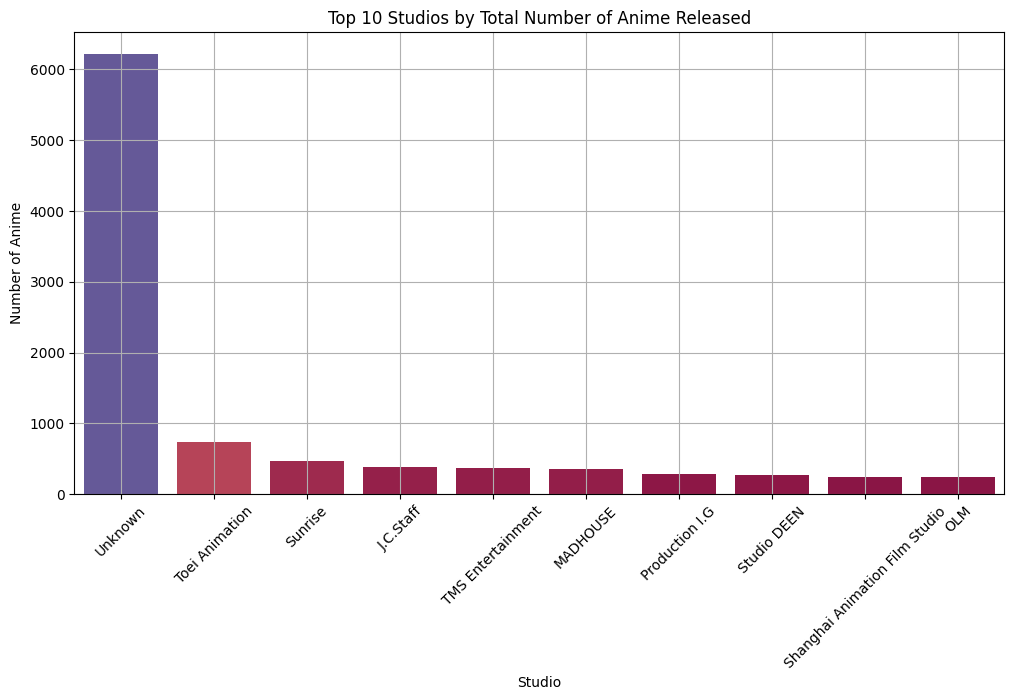

In [22]:
#top 10 studioes with large numbe rof anime release
# Count number of anime per studio
studio_counts = anime_original_df['studio'].value_counts().head(10)

# Plot vertical bar chart
plt.figure(figsize=(12,6))
sns.barplot(x=studio_counts.index, y=studio_counts.values,hue=studio_counts.values,legend=False, palette='Spectral')



plt.title('Top 10 Studios by Total Number of Anime Released')
plt.xlabel('Studio')
plt.ylabel('Number of Anime')
plt.xticks(rotation=45)
plt.grid()
plt.show()




From the Above observation, we see that studio with unknown value has the highest number of anime released. So lets see the visualization for the next values ignoring the unknow values.

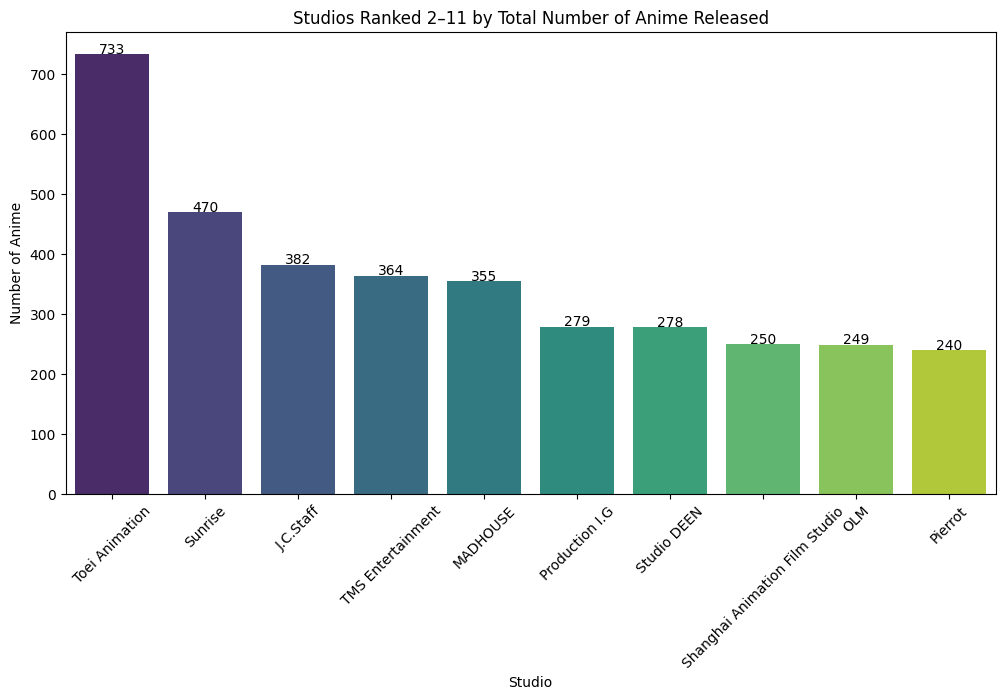

In [23]:
studio_counts_new = anime_original_df['studio'].value_counts()
# Take top 10 but skip the first one
studio_counts = studio_counts_new.iloc[1:11]  # Skips index 0, takes next 10 studios


plt.figure(figsize=(12,6))
sns.barplot(x=studio_counts.index, y=studio_counts.values,hue=studio_counts.index,legend=False, palette='viridis')

# Add count labels on top of bars
for i, v in enumerate(studio_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.title('Studios Ranked 2–11 by Total Number of Anime Released')
plt.xlabel('Studio')
plt.ylabel('Number of Anime')
plt.xticks(rotation=45)
plt.show()


We see that Toei Animation has he largest anime released followed by sunrise.

Summary Statistics:

In [24]:
#View statistical data
anime_original_df.describe()

,rank,rating,release_year
count,18112.000000,18112.000000,18112.0
mean,9093.620031,3.356045,2006.520318
std,5278.196185,0.368696,15.189537
min,1.000000,0.960000,1907.0
25%,4530.750000,3.170000,2001.0
50%,9068.500000,3.360000,2012.0
75%,13601.250000,3.540000,2017.0
max,18495.000000,4.600000,2023.0
